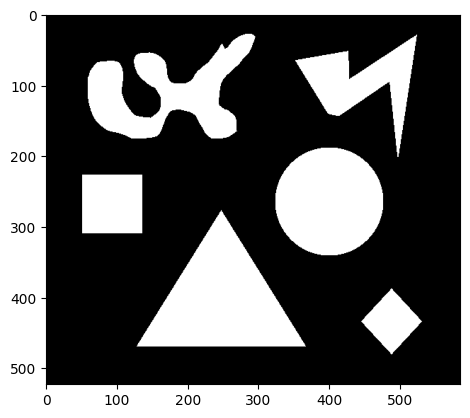

In [8]:
# UMBRALIZACIÓN CON OTSU COMO PASO PREVIO A SEGMENTACIÓN

import matplotlib.pyplot as plt
import cv2
import numpy as np

# Cargar imagen y convertir a grises
img      = cv2.imread('images/figuras.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Aplicar umbral automático de Otsu
# 0   → umbral inicial (Otsu lo ignora y lo calcula solo)
# 1   → valor máximo de la máscara (0 o 1, no 0 o 255)
# Devuelve: t = umbral encontrado, mask = imagen binaria
_, mask = cv2.threshold(img_gray, 0, 1, cv2.THRESH_OTSU)

# Mostrar la máscara binaria resultante
plt.imshow(mask, cmap='gray')
plt.show()

A cada objeto le damos una etiqueta distinta.     
Estas etiquetas nos permitiran trabajar de forma aislada con cada objeto.

número de objetos:  6
posibles valores de intensidad:  [0 1 2 3 4 5 6]


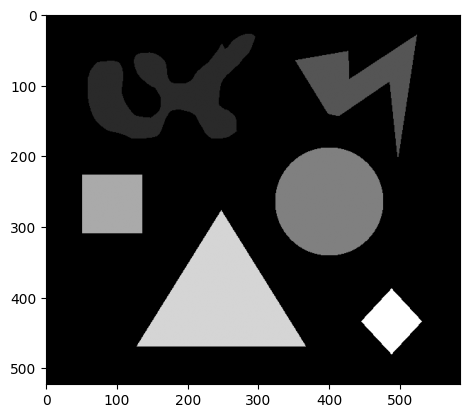

In [11]:
# ETIQUETADO DE COMPONENTES CONEXAS
  # convertimos la imagen binaria en una imagen de estiquetas para tener acceso a cada objeto por separado
from skimage.measure import label

# label() asigna un número único a cada objeto separado (componente conexa)
# return_num=True → devuelve también el número de objetos encontrados
# lab  → imagen donde cada objeto tiene un valor distinto (1,2,3...)
# num  → número de objetos encontrados (sin contar el fondo)
lab, num = label(mask, return_num=True)

print('número de objetos: ', num)

# np.unique con return_counts=True devuelve:
# v → valores únicos en lab (0=fondo, 1,2,3...=objetos)
# c → cuántos píxeles tiene cada etiqueta
v, c = np.unique(lab, return_counts=True)
print('posibles valores de intensidad: ', v)

# Visualizar: cada objeto se ve con un tono de gris diferente
plt.imshow(lab, cmap='gray')
plt.show()

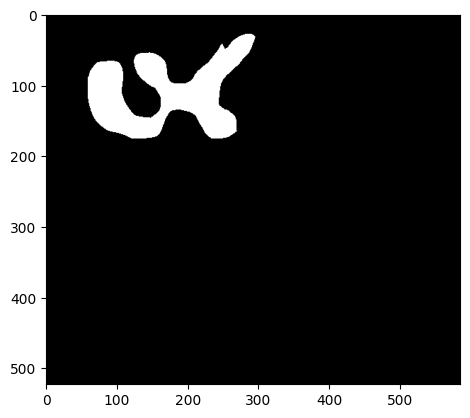

In [12]:
# Podemos acceder de manera independiente al objeto que nos interese a partir de su etiqueta correspondiente
objeto = lab == 1
objeto = objeto.astype('uint8')
plt.imshow(objeto, cmap='gray')
plt.show()

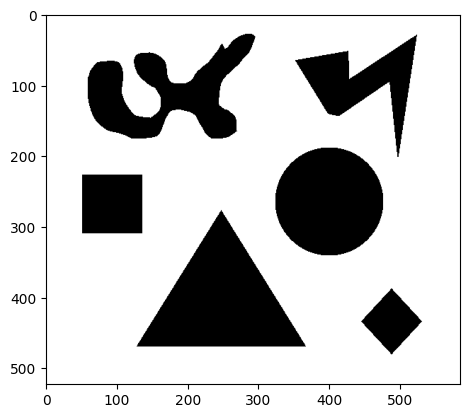

In [14]:
# Podemos acceder de manera independiente al objeto que nos interese a partir de su etiqueta correspondiente
objeto = lab == 0 # = representa el fondo
objeto = objeto.astype('uint8')
plt.imshow(objeto, cmap='gray')
plt.show()

(28, 59, 176, 296)


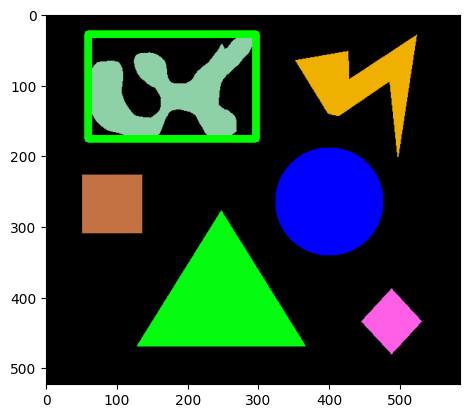

In [17]:
from skimage.measure import regionprops
# https://scikit-image.org/docs/dev/api/skimage.measure.html#skimage.measure.regionprops

# Extraer propiedades geométricas del objeto etiquetado
# (regionprops espera una imagen etiquetada con enteros)
prop = regionprops(objeto)

# bbox devuelve (min_row, min_col, max_row, max_col) → formato (y1, x1, y2, x2)
bbox = prop[0].bbox # rectangulo minimo, se forma por coordenadas
print(bbox) # nos muestra las coordenadas

# Convertir al formato de cv2.rectangle que usa (x, y) en vez de (row, col)
start_point = (bbox[1], bbox[0])  # esquina superior izquierda (x1, y1)
end_point   = (bbox[3], bbox[2])  # esquina inferior derecha   (x2, y2)

# Dibujar el bounding box en verde (0,255,0) con grosor 10 sobre la imagen original
window = cv2.rectangle(img.copy(), start_point, end_point, (0, 255, 0), 10)

plt.imshow(window, cmap='gray')
plt.show()

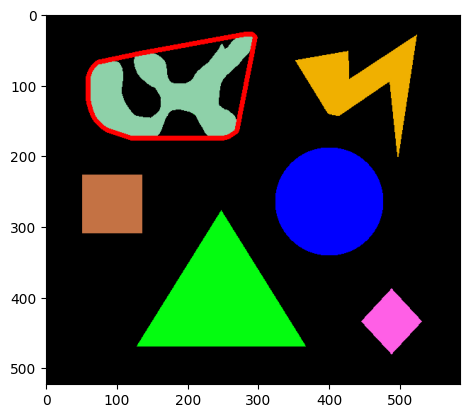

In [19]:
# CONVEX HULL (ENVOLVENTE CONVEXA)

from skimage.morphology import convex_hull_image

# convex_hull_image calcula el polígono convexo más pequeño que contiene el objeto
# Es decir, "rellena" las concavidades del objeto hasta formar una forma convexa
convex_image = convex_hull_image(objeto)
convex_image = convex_image.astype('uint8')  # convertir de bool a uint8 para OpenCV

# Descomentar para ver la convex hull como máscara binaria
# plt.imshow(convex_image, cmap='gray')
# plt.show()

# Encontrar los contornos del polígono convexo
# cv2.RETR_TREE      → recupera todos los contornos en jerarquía
# cv2.CHAIN_APPROX_SIMPLE → comprime segmentos horizontales/verticales (ahorra memoria)
conts, _ = cv2.findContours(convex_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Dibujar los contornos en azul (255,0,0 en BGR) con grosor 5
# -1 → dibuja todos los contornos encontrados
imagen = cv2.drawContours(img.copy(), conts, -1, (255, 0, 0), 5)

plt.imshow(imagen, cmap='gray')
plt.show()

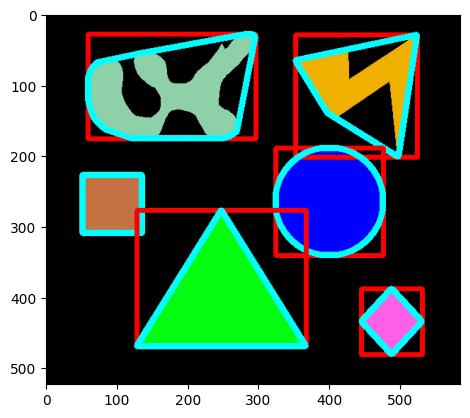

In [21]:
# PROCESAR TODOS LOS OBJETOS DE LA IMAGEN EN UN BUCLE

imagen = img.copy()

# Iteramos sobre cada objeto etiquetado (del 1 al num, el 0 es el fondo)
for i in range(1, num+1):
    # Extraer el objeto i como máscara binaria
    objeto = lab == i          # True donde lab vale i, False en el resto
    objeto = objeto.astype('uint8')  # convertir bool → uint8 para OpenCV

    # --- BOUNDING BOX ---
    prop = regionprops(objeto)
    bbox = prop[0].bbox        # (min_row, min_col, max_row, max_col)
    # Dibujar rectángulo azul (255,0,0 en BGR) con grosor 5
    imagen = cv2.rectangle(imagen, (bbox[1], bbox[0]), (bbox[3], bbox[2]), (255, 0, 0), 5)

    # --- CONVEX HULL ---
    convex_image = convex_hull_image(objeto)
    convex_image = convex_image.astype('uint8')
    conts, _ = cv2.findContours(convex_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    # Dibujar contorno convexo en amarillo (0,255,255 en BGR) con grosor 8
    imagen = cv2.drawContours(imagen, conts, -1, (0, 255, 255), 8)

plt.imshow(imagen, cmap='gray')
plt.show()

In [24]:
# DESCRIPTORES GEOMÉTRICOS DE CADA OBJETO

from tabulate import tabulate
import math

# Re-etiquetar la máscara (mismo proceso que antes)
new_lab, new_num = label(mask, return_num=True)

# Cabecera de la tabla: nombre de cada objeto
headers = ['', 'Raro', 'Rayo', 'Círculo', 'Cuadrado', 'Triángulo', 'Rombo']

# Inicializar listas con el nombre del descriptor como primer elemento
A,BB,CA,E,ED,EX,MA,MiA,OR,P,S,CO,R = ['area'], ['bbox_area'], ['convex_area'], ['eccentricity'], ['equiv_diameter'], \
['extent'], ['major_axis'], ['minor_axis'], ['orientation'], ['perimeter'], ['solidity'], ['compactness'], ['rectangularity']

for i in range(1, new_num+1):
    objeto = new_lab == i
    prop = regionprops(objeto.astype(np.uint8))

    A.append(np.round(prop[0].area, 4))                    # nº de píxeles del objeto
    BB.append(np.round(prop[0].bbox_area, 4))              # área del bounding box
    CA.append(np.round(prop[0].convex_area, 4))            # área de la convex hull
    E.append(np.round(prop[0].eccentricity, 4))            # 0=círculo perfecto, 1=línea
    ED.append(np.round(prop[0].equivalent_diameter, 4))    # diámetro de un círculo con la misma área
    EX.append(np.round(prop[0].extent, 4))                 # ratio área_objeto / área_bbox
    MA.append(np.round(prop[0].major_axis_length, 4))      # eje mayor de la elipse equivalente
    MiA.append(np.round(prop[0].minor_axis_length, 4))     # eje menor de la elipse equivalente
    OR.append(np.round(prop[0].orientation, 4))            # ángulo de orientación (radianes)
    P.append(np.round(prop[0].perimeter, 4))               # perímetro del objeto
    S.append(np.round(prop[0].solidity, 4))                # ratio área / convex_area (1=sólido)
    CO.append(np.round(4*math.pi*prop[0].area/prop[0].perimeter**2, 4))  # compacidad: 1=círculo perfecto
    R.append(np.round(prop[0].area/prop[0].bbox_area, 4))  # rectangularidad: ratio área / bbox

# Construir e imprimir la tabla
my_data = [tuple(A), tuple(BB), tuple(CA), tuple(E), tuple(ED), tuple(EX), \
          tuple(MA), tuple(MiA), tuple(OR), tuple(P), tuple(S), tuple(CO), tuple(R)]

print(tabulate(my_data, headers=headers))

                      Raro        Rayo     Círculo    Cuadrado    Triángulo      Rombo
--------------  ----------  ----------  ----------  ----------  -----------  ---------
area            16198       10282       18344        7055        23119       4018
bbox_area       35076       29756       23104        7055        46127       7998
convex_area     27405       16959       18488        7055        23307       4102
eccentricity        0.8556      0.7941      0           0.2157       0.371      0.3866
equiv_diameter    143.61      114.418     152.828      94.7771     171.569     71.5254
extent              0.4618      0.3455      0.794       1            0.5012     0.5024
major_axis        268.45      186.995     152.828      98.1428     195.774     76.1969
minor_axis        138.975     113.644     152.828      95.8332     181.801     70.2735
orientation        -1.4236      1.5298     -0.7854      1.5708      -1.5708     0
perimeter        1029.77      736.02      503.245     332      